# Federated learning: ECI 2026 Project

In this project I'm going to be building a skeleton federated learning system while also providing some insights on the model.

## SETUP

First we need to install Tensorflow (and it's datasets) & MatPlotLib 

In [22]:
!pip install -q matplotlib
!pip install -q tensorflow
!pip install -q numpy
!pip install -q pandas
!pip install -q scikit-learn

Then we import it

In [23]:
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

## Dataset

I'm going to be using [CIFAR10](https://www.tensorflow.org/datasets/catalog/cifar10?hl=es), a dataset containing 60000 32x32 colour images uniformly distributed amongst 10 classes. 

We want an equal label-wise distribution using a **60/10/30** split for training, validation & test, for that reason we must stratify the split using the labels 

> The dataset itself is pre-split so we need to recombine it and then split it

In [27]:
(X_train_original, Y_train_original), (X_test_original, Y_test_original) = tf.keras.datasets.cifar10.load_data()

X_unified = np.concatenate([X_train_original, X_test_original])
Y_unified = np.concatenate([Y_train_original, Y_test_original])

Y_unified = Y_unified.flatten()

# First we take the 60% split
X_train, X_temp, Y_train, y_temp = train_test_split(
    X_unified, Y_unified,
    test_size=0.40,      
    random_state=42,
    stratify=Y_unified   
)

# Then we split the remaining 40% of the dataset into 10/30
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.75,      
    random_state=42,
    stratify=y_temp      
)

## Dataset Analysis

Now we can plot and visualize some of the data distribution, in particular we can see

1.  Histogram of the classes
2.  Few samples

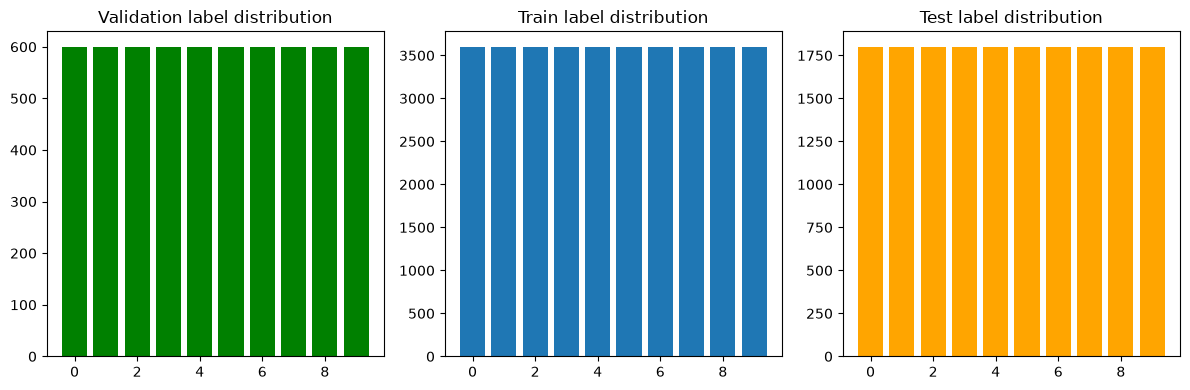

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(np.unique_counts(Y_val).values, np.unique_counts(Y_val).counts, color="green")
axes[0].set_title("Validation label distribution")
axes[1].bar(np.unique_counts(Y_train).values, np.unique_counts(Y_train).counts)
axes[1].set_title("Train label distribution")
axes[2].bar(np.unique_counts(Y_test).values, np.unique_counts(Y_test).counts, color="orange")
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

As we can see there is no (centralized) data skewness because all labels have exactly 6000 samples (although we will split it into non-IID scenarios).

Let's visualize some samples of the images to get a general idea of what they look like

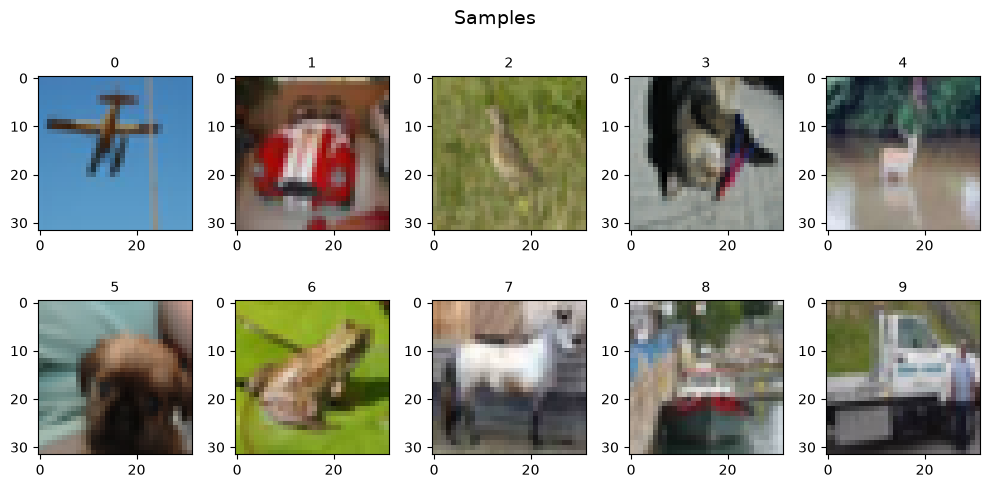

In [42]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

axes_flat = axes.flatten()

for i in range(10):
    j = 0
    while Y_val[j] != i:
        j += 1
        
    if j < len(Y_val):
        ax = axes_flat[i]
        ax.imshow(X_val[j])
        ax.set_title(f"{Y_val[j]}", fontsize=10)

plt.suptitle("Samples", fontsize=14)
plt.tight_layout()
plt.show()